In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/notebooks/jan2026/srppac/parquet/run1083_srppac_koji.parquet")#.select("id_x","timing_x","charge_x","id_y","timing_y","charge_y")
df.show(15)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/29 11:21:10 WARN Utils: Your hostname, gpuana02, resolves to a loopback address: 127.0.1.1; using 133.11.152.134 instead (on interface enp4s0)
26/01/29 11:21:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/01/29 11:21:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/29 11:21:10 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


+---------+------------+--------------------+--------------------+------+-------------------+------------------+------------------+------------------+-----+-----+-----+--------------------+------------------+--------------------+--------------------+------+-------------------+------------------+------------------+------------------+-----+-----+-----+-------------------+-------+
|hbfNumber|        id_x|            timing_x|            charge_x|size_x|          timing0_x|         charge0_x|         charge1_x|         charge2_x|id0_x|id1_x|id2_x|              q0q1_x|              id_y|            timing_y|            charge_y|size_y|          timing0_y|         charge0_y|         charge1_y|         charge2_y|id0_y|id1_y|id2_y|             q0q1_y|runname|
+---------+------------+--------------------+--------------------+------+-------------------+------------------+------------------+------------------+-----+-----+-----+--------------------+------------------+--------------------+---------

Statistics:
[[    0.     0.     0.]
 [    0. 72594.     0.]
 [    0.    99.     0.]]
Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 8.2151e+04 0.0000e+00]
 [0.0000e+00 5.6000e+01 0.0000e+00]]
Statistics:
[[0.0000e+00 2.6000e+01 0.0000e+00]
 [0.0000e+00 7.2667e+04 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00]]
Statistics:
[[0.0000e+00 2.1000e+01 0.0000e+00]
 [0.0000e+00 8.2186e+04 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00]]


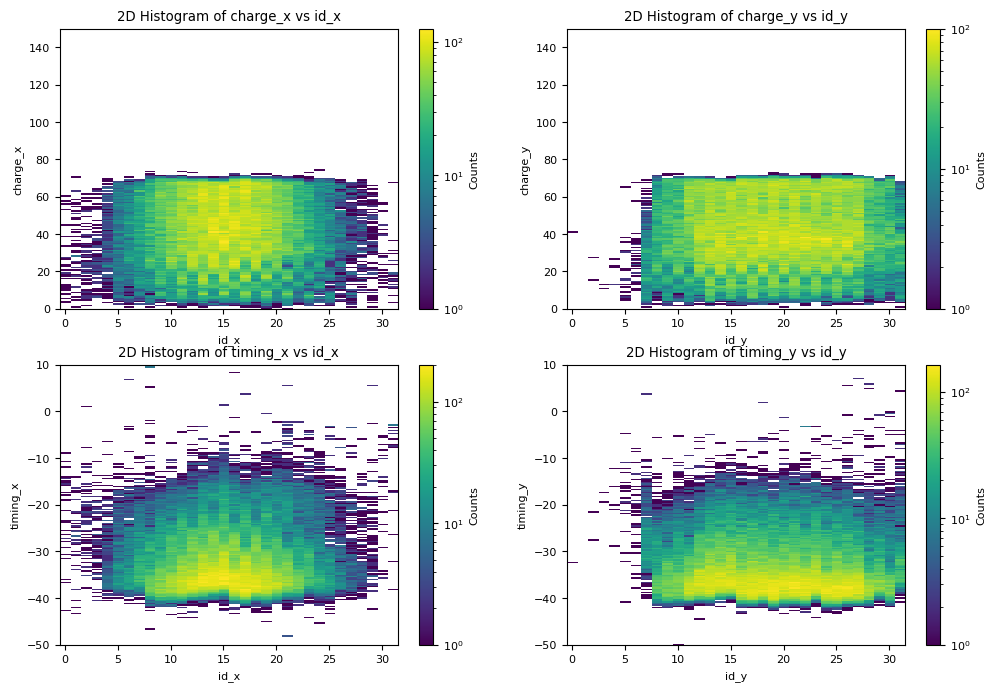

In [2]:
from hist.sparkHist2d import Hist2DArrays
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,8))
plt.rcParams["font.size"] = 8
plt.subplot2grid((2,2),(0,0))
h = Hist2DArrays(df, ["id_x","charge_x"], [33,200], [[-0.5, 31.5], [0, 150]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(0,1))
h = Hist2DArrays(df, ["id_y","charge_y"], [33,200], [[-0.5, 31.5], [0, 150]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,0))
h = Hist2DArrays(df, ["id_x","timing_x"], [33,200], [[-0.5, 31.5], [-50, 10]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,1))
h = Hist2DArrays(df, ["id_y","timing_y"], [33,200], [[-0.5, 31.5], [-50, 10]], norm=LogNorm(), interpolation='none')

plt.show()